[Yao et al. 2022](https://arxiv.org/abs/2210.03629) call their pattern **ReAct**: the model interleaves *Thought* (free-form reasoning) with *Action* (a structured tool call). The runtime executes the action, returns an *Observation*, and the loop continues until the model emits `Finish[answer]`.

The interesting question isn't "does ReAct work" — it's **how much does the loop actually buy you over the simpler alternatives**. The four paradigms below are the spectrum, and we'll run each of four representative questions through all four to see where the gap opens.

Everything runs locally on Gemma 4 31B (4-bit MLX) — multimodal, ~19 GB peak on an M2 Max, ~15 tokens/sec.

## The four paradigms

![Direct · CoT · Acting only · ReAct](images/paradigms.svg)

| Paradigm | What it does | When it wins | Where it loses |
|---|---|---|---|
| **1. Direct answer** | Question → LLM → answer | Fact already memorised; trivial reasoning | Anything beyond training data; arithmetic; live state |
| **2. Reasoning only (CoT)** | Question → LLM thinks step-by-step → answer | Multi-step *inferences* that don't need fresh facts | Multi-digit math; today's date; unseen images |
| **3. Acting only** | Question → LLM picks tool → observation → loop → answer | Pure look-up tasks | Tasks needing planning between calls; the model loses the thread |
| **4. ReAct** | Question → Thought → Action → Observation → loop → answer | Multi-hop with tools; needs both *what next* and *do it* | Format-fragile on small models; cheap calls (overhead doesn't pay off) |

## Setup

One model, one ReAct loop, three text tools (`search`, `calc`, `date_diff`), two vision tools (`describe`, `crop`). Code is folded by default; click *Show code* to expand.

In [1]:
import time, re, datetime, ast, operator, math, io, contextlib
from pathlib import Path
from PIL import Image
from IPython.display import display, Markdown

from mlx_vlm import load as load_vlm, generate as vlm_generate
from mlx_vlm.prompt_utils import apply_chat_template
from mlx_vlm.utils import load_config

MODEL_ID = 'mlx-community/gemma-4-31b-it-4bit'
_state = {}

def get_model():
    if 'model' not in _state:
        t0 = time.time()
        _state['model'], _state['proc'] = load_vlm(MODEL_ID)
        _state['cfg'] = load_config(MODEL_ID)
        print(f'[load] {time.time()-t0:.1f}s')
    return _state['model'], _state['proc'], _state['cfg']

def llm(prompt, images=None, max_tokens=400):
    model, proc, cfg = get_model()
    images = images or []
    formatted = apply_chat_template(proc, cfg, prompt, num_images=len(images))
    out = vlm_generate(model, proc, formatted, image=images,
                       max_tokens=max_tokens, verbose=False)
    return out.text

In [2]:
# ---------- ReAct loop (with the small-model guardrails) ----------
_ACTION_RE = re.compile(
    r"(?:^|\n)\s*(?:Action(?:\s*\d*)?:\s*)?(\w+)\s*\[(.*?)\]\s*(?:\n|$)",
    re.DOTALL,
)
_FINISH_COLON = re.compile(r"(?:^|\n)\s*Finish\s*:\s*(.+?)(?:\n|$)", re.DOTALL)

class _FinishMatch:
    def __init__(self, m): self._m = m; self._end = m.end()
    def group(self, i): return 'Finish' if i == 1 else self._m.group(1).strip()
    def end(self): return self._end

def _strip_leaks(text):
    text = re.sub(r"<[^<>]*\|>", "", text)
    for marker in ("\nObservation", "\n观察结果", "\n观察"):
        idx = text.find(marker, 1)
        if idx > 0: text = text[:idx]
    return text.strip()

def _find_action(out, valid):
    for m in _ACTION_RE.finditer(out):
        if m.group(1) in valid: return m
    fm = _FINISH_COLON.search(out)
    if fm: return _FinishMatch(fm)
    return None

def react(question, tools, system, images=None,
          max_steps=6, max_tokens_per_step=900, verbose=True):
    valid = set(tools) | {'Finish'}
    trace = system.strip() + '\n\nQuestion: ' + question.strip() + '\n'
    if verbose: print(trace, end='')
    for step in range(1, max_steps + 1):
        prompt = trace + f'\nThought {step}:'
        out = _strip_leaks(llm(prompt, images=images, max_tokens=max_tokens_per_step))
        m = _find_action(out, valid)
        if not m:
            forced = _strip_leaks(llm(
                trace + f'\nThought {step}: ' + out.strip() +
                f'\n\nReply with ONLY the next line:\nAction {step}: tool_name[arg]\n',
                images=images, max_tokens=80))
            m = _find_action(forced, valid)
            if m: out = (out.rstrip() + '\n' + forced)
            else:
                if verbose: print(f'\n[step {step}: no Action]')
                return None
        out = out[:m.end()]
        chunk = f'\nThought {step}:{"" if out.startswith(chr(10)) else " "}{out.rstrip()}'
        chunk = re.sub(r'^\nThought (\d+):\s*Thought \1:\s*', r'\nThought \1: ', chunk)
        if verbose: print(chunk, end='')
        trace += chunk
        name, arg = m.group(1).strip(), m.group(2).strip()
        if name == 'Finish':
            if verbose: print(f'\n\n=> {arg}')
            return arg
        try:
            obs = str(tools[name](arg))[:600]
        except Exception as e:
            obs = f'tool error: {type(e).__name__}: {e}'
        addition = f'\nObservation {step}: {obs}'
        if verbose: print(addition, end='')
        trace += addition
    if verbose: print('\n[max steps]')
    return None

In [3]:
# ---------- text tools ----------
import wikipedia
wikipedia.set_lang('en')

def tool_search(query):
    try:
        return wikipedia.summary(query, sentences=2, auto_suggest=True)
    except wikipedia.DisambiguationError as e:
        return 'disambiguation: ' + ', '.join(e.options[:6])
    except wikipedia.PageError:
        return f'no exact page; nearest: {wikipedia.search(query)[:5]}'

_OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul,
        ast.Div: operator.truediv, ast.Pow: operator.pow, ast.USub: operator.neg,
        ast.Mod: operator.mod, ast.FloorDiv: operator.floordiv}
_FNS = {'sqrt': math.sqrt, 'log': math.log, 'log10': math.log10, 'exp': math.exp,
        'sin': math.sin, 'cos': math.cos, 'pi': math.pi,
        'round': round, 'abs': abs, 'min': min, 'max': max}
def _eval(node):
    if isinstance(node, ast.Constant): return node.value
    if isinstance(node, ast.BinOp):    return _OPS[type(node.op)](_eval(node.left), _eval(node.right))
    if isinstance(node, ast.UnaryOp):  return _OPS[type(node.op)](_eval(node.operand))
    if isinstance(node, ast.Call):     return _FNS[node.func.id](*[_eval(a) for a in node.args])
    if isinstance(node, ast.Name):     return _FNS[node.id]
    raise ValueError(f'bad node {ast.dump(node)}')
def tool_calc(expr):
    expr = expr.strip().strip("'\"")
    return _eval(ast.parse(expr, mode='eval').body)

def tool_today(_=''): return datetime.date.today().isoformat()
def tool_date_diff(arg):
    a, b = [s.strip() for s in arg.split(',')]
    return str((datetime.date.fromisoformat(b) - datetime.date.fromisoformat(a)).days)

TEXT_TOOLS = {'search': tool_search, 'calc': tool_calc,
              'today': tool_today, 'date_diff': tool_date_diff}

TEXT_SYSTEM = '''You answer the user's question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]      - returns a short Wikipedia summary
  calc[expr]         - evaluates a Python arithmetic expression
  today[]            - returns today's date as YYYY-MM-DD
  date_diff[d1, d2]  - days from d1 to d2 (both YYYY-MM-DD)
  Finish[answer]     - emit the final concise answer and stop

Format:
  Thought N: short reasoning
  Action N: tool_name[argument]
Stop within 5 steps via Finish[your answer].'''

# ---------- vision tools ----------
_current_image = {'pil': None}

def look_at(path):
    img = Image.open(path).convert('RGB')
    _current_image['pil'] = img
    return img

def tool_describe(_=''):
    img = _current_image['pil']
    if img is None: return 'no image loaded'
    return llm('Describe everything visible. Note any text, numbers, or countable objects.',
               images=[img], max_tokens=240).strip()

def tool_crop(arg):
    img = _current_image['pil']
    if img is None: return 'no image loaded'
    parts = [float(x.strip()) for x in arg.split(',')]
    if len(parts) != 4: return 'crop expects "x1,y1,x2,y2"'
    W, H = img.size
    pixels = max(parts) > 1.5
    x1, y1, x2, y2 = (parts if pixels else
                      [parts[0]*W, parts[1]*H, parts[2]*W, parts[3]*H])
    x1, x2 = sorted([max(0, x1), min(W, x2)])
    y1, y2 = sorted([max(0, y1), min(H, y2)])
    if x2 - x1 < 4 or y2 - y1 < 4: return 'crop too small'
    crop = img.crop((int(x1), int(y1), int(x2), int(y2)))
    return llm('Describe this crop in one sentence focused on the relevant detail.',
               images=[crop], max_tokens=120).strip()

VISION_TOOLS = {'describe': tool_describe, 'crop': tool_crop, 'calc': tool_calc}

VISION_SYSTEM = '''You answer a question about an image by interleaving Thought, Action, and Observation.
Available tools:
  describe[]            - one full description of the image
  crop[x1,y1,x2,y2]     - re-look at a region (normalised 0..1 OR pixels)
  calc[expr]            - evaluate a numerical expression
  Finish[answer]        - final concise answer, stop

Format:
  Thought N: short reasoning
  Action N: tool_name[argument]
Use describe[] first; use crop[] to inspect a region. Stop within 5 steps with Finish[answer].'''

In [4]:
# ---------- 4-paradigm comparison helper (full traces shown) ----------
import html as _html

def _capture(fn, *a, **k):
    """Run fn() with stdout redirected; return (return_value, captured_text)."""
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        result = fn(*a, **k)
    return result, buf.getvalue()

def direct(question, images=None):
    raw = llm(f'Answer the question concisely in one short line.\n\nQuestion: {question}\nAnswer:',
              images=images, max_tokens=160)
    raw = _strip_leaks(raw)
    answer = raw.split('\n')[0].strip()
    trace = f'PROMPT:\nAnswer the question concisely in one short line.\nQuestion: {question}\nAnswer:\n\nMODEL OUTPUT:\n{raw}'
    return answer, trace

def cot(question, images=None):
    prompt = ('Think step by step in plain text, then on the LAST line write '
              "'Final answer: <answer>'.\n\nQuestion: " + question + '\n\nReasoning:')
    raw = llm(prompt, images=images, max_tokens=1400).strip()
    answer = '(no answer)'
    for line in reversed(raw.splitlines()):
        if line.lower().lstrip().startswith('final answer'):
            answer = line.split(':', 1)[-1].strip(); break
    trace = f'PROMPT:\n{prompt}\n\nMODEL OUTPUT:\n{raw}'
    return answer, trace

def act_only(question, tools, base_system, images=None):
    sys = ('You answer by emitting Action lines only. Do NOT think aloud. '
           'Each step is exactly one Action: tool[arg]. Stop with Finish[answer].\n'
           'Available tools: ' + ', '.join(sorted(set(tools) | {"Finish"})))
    answer, trace = _capture(react, question, tools, sys, images=images,
                             max_steps=4, max_tokens_per_step=120, verbose=True)
    return (answer or '(failed)'), trace

def react_full(question, tools, system, images=None):
    answer, trace = _capture(react, question, tools, system,
                             images=images, verbose=True)
    return (answer or '(failed)'), trace

_CSS_INJECTED = [False]
_TRACE_CSS = """
<style>
  .react-trace-block { font-size: 14px; line-height: 1.55; }
  .react-trace-block table { font-size: 14px; }
  .react-trace-block table td, .react-trace-block table th { color: var(--bs-body-color, #1a1a1a) !important; padding: 6px 10px; }
  .react-trace-block summary { font-size: 14.5px; padding: 6px 0; cursor: pointer; }
  .react-trace-block summary b { color: var(--bs-body-color, #1a1a1a); }
  .react-trace-block em, .react-trace-block i { color: var(--bs-body-color, #1a1a1a); }
  .react-trace-block code { font-size: 13px; }
</style>
"""

def _esc(s, max_len=12000):
    s = str(s)
    if len(s) > max_len: s = s[:max_len] + "\n…(truncated)"
    return _html.escape(s)

def compare(question, tools, system, images=None, ground_truth=None, image_label=''):
    rows = [
        ('1. Direct',   *direct(question, images)),
        ('2. CoT',      *cot(question, images)),
        ('3. Act-only', *act_only(question, tools, system, images)),
        ('4. ReAct',    *react_full(question, tools, system, images)),
    ]
    md = []
    if not _CSS_INJECTED[0]:
        md.append(_TRACE_CSS); _CSS_INJECTED[0] = True
    md.append('<div class="react-trace-block">')
    md.append('**Question:** ' + question)
    if image_label: md.append(f'\n*Image: {image_label}*')
    if ground_truth is not None: md.append(f'\n*Ground truth:* `{ground_truth}`')
    md.append('\n| Paradigm | Final answer |\n|---|---|')
    for name, ans, _ in rows:
        a = str(ans).replace('|', '\\|').replace('\n', '<br>')
        if len(a) > 220: a = a[:220] + '…'
        md.append(f'| **{name}** | {a} |')
    md.append('')
    md.append('### Full traces')
    for name, _, trace in rows:
        md.append(
            f'<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>{name}</b> — click to expand full trace</summary>\n'
            f'<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">{_esc(trace)}</pre>\n'
            f'</details>')
    md.append('</div>')
    display(Markdown('\n'.join(md)))
    return rows


## Q1 — Multi-hop QA (search-heavy)

Two facts to bridge. Direct/CoT only succeed if both facts happen to be in the model's memory; ReAct can verify and correct.

In [5]:
_ = compare(
    'What country was the inventor of the Linux kernel born in, and what is the capital of that country?',
    TEXT_TOOLS, TEXT_SYSTEM,
    ground_truth='Finland; Helsinki')

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

[load] 5.9s



<style>
  .react-trace-block { font-size: 14px; line-height: 1.55; }
  .react-trace-block table { font-size: 14px; }
  .react-trace-block table td, .react-trace-block table th { color: var(--bs-body-color, #1a1a1a) !important; padding: 6px 10px; }
  .react-trace-block summary { font-size: 14.5px; padding: 6px 0; cursor: pointer; }
  .react-trace-block summary b { color: var(--bs-body-color, #1a1a1a); }
  .react-trace-block em, .react-trace-block i { color: var(--bs-body-color, #1a1a1a); }
  .react-trace-block code { font-size: 13px; }
</style>

<div class="react-trace-block">
**Question:** What country was the inventor of the Linux kernel born in, and what is the capital of that country?

*Ground truth:* `Finland; Helsinki`

| Paradigm | Final answer |
|---|---|
| **1. Direct** | Finland; Helsinki. |
| **2. CoT** | Finland, Helsinki |
| **3. Act-only** | Linus Torvalds, the inventor of the Linux kernel, was born in Finland, and its capital is Helsinki. |
| **4. ReAct** | Finland, Helsinki |

### Full traces
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>1. Direct</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">PROMPT:
Answer the question concisely in one short line.
Question: What country was the inventor of the Linux kernel born in, and what is the capital of that country?
Answer:

MODEL OUTPUT:
Finland; Helsinki.</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>2. CoT</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">PROMPT:
Think step by step in plain text, then on the LAST line write &#x27;Final answer: &lt;answer&gt;&#x27;.

Question: What country was the inventor of the Linux kernel born in, and what is the capital of that country?

Reasoning:

MODEL OUTPUT:
1. Identify the inventor of the Linux kernel: The Linux kernel was created by Linus Torvalds.
2. Determine the country of birth for Linus Torvalds: Linus Torvalds was born in Finland.
3. Identify the capital of Finland: The capital of Finland is Helsinki.

Final answer: Finland, Helsinki</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>3. Act-only</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">You answer by emitting Action lines only. Do NOT think aloud. Each step is exactly one Action: tool[arg]. Stop with Finish[answer].
Available tools: Finish, calc, date_diff, search, today

Question: What country was the inventor of the Linux kernel born in, and what is the capital of that country?

Thought 1: search[inventor of the Linux kernel]
Observation 1: Linus Benedict Torvalds (born 28 December 1969) is a Finnish and American software engineer who is the creator and lead developer of the Linux kernel since 1991. He also created the distributed version control system Git.
Thought 2: search[capital of Finland]
Observation 2: Helsinki (Swedish: Helsingfors) is the capital and most populous city in Finland. It is on the shore of the Gulf of Finland and is the seat of southern Finland&#x27;s Uusimaa region.
Thought 3: Finish[Linus Torvalds, the inventor of the Linux kernel, was born in Finland, and its capital is Helsinki.]

=&gt; Linus Torvalds, the inventor of the Linux kernel, was born in Finland, and its capital is Helsinki.
</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>4. ReAct</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">You answer the user&#x27;s question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]      - returns a short Wikipedia summary
  calc[expr]         - evaluates a Python arithmetic expression
  today[]            - returns today&#x27;s date as YYYY-MM-DD
  date_diff[d1, d2]  - days from d1 to d2 (both YYYY-MM-DD)
  Finish[answer]     - emit the final concise answer and stop

Format:
  Thought N: short reasoning
  Action N: tool_name[argument]
Stop within 5 steps via Finish[your answer].

Question: What country was the inventor of the Linux kernel born in, and what is the capital of that country?

Thought 1: The inventor of the Linux kernel is Linus Torvalds. I need to find his birth country and the capital of that country.

Thought 1: Identify the inventor of the Linux kernel and their birth country.
Action 1: search[Linus Torvalds]
Observation 1: Linus Benedict Torvalds (born 28 December 1969) is a Finnish and American software engineer who is the creator and lead developer of the Linux kernel since 1991. He also created the distributed version control system Git.
Thought 2: Linus Torvalds was born in Finland. Now I need to find the capital of Finland.
Action 2: search[Finland]
Observation 2: An island or isle is a piece of land, distinct from a continent, completely surrounded by water. There are continental islands, which were formed by being split from a continent by plate tectonics, and oceanic islands, which have never been part of a continent.
Thought 3: The previous search for &quot;Finland&quot; returned irrelevant information about islands. I need to specifically search for the capital of Finland.
Action 3: search[capital of Finland]
Observation 3: Helsinki (Swedish: Helsingfors) is the capital and most populous city in Finland. It is on the shore of the Gulf of Finland and is the seat of southern Finland&#x27;s Uusimaa region.
Thought 4: The inventor of the Linux kernel, Linus Torvalds, was born in Finland, and the capital of Finland is Helsinki.

Finish[Finland, Helsinki]

=&gt; Finland, Helsinki
</pre>
</details>
</div>

## Q2 — Compound interest (calculator-heavy)

Multi-digit arithmetic over nine compoundings. Small-to-medium models can't do this in their heads; the question is whether each paradigm knows to *defer* to a calculator.

In [6]:
_ = compare(
    'If I invest 47,500 INR at 7.25% annual compound interest for 9 years, how much will it grow to? Round to the nearest rupee.',
    TEXT_TOOLS, TEXT_SYSTEM,
    ground_truth=f'{round(47500 * 1.0725**9):,} INR')

<div class="react-trace-block">
**Question:** If I invest 47,500 INR at 7.25% annual compound interest for 9 years, how much will it grow to? Round to the nearest rupee.

*Ground truth:* `89,180 INR`

| Paradigm | Final answer |
|---|---|
| **1. Direct** | 92,354 INR |
| **2. CoT** | 89135 |
| **3. Act-only** | 89180 |
| **4. ReAct** | 89,180 INR |

### Full traces
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>1. Direct</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">PROMPT:
Answer the question concisely in one short line.
Question: If I invest 47,500 INR at 7.25% annual compound interest for 9 years, how much will it grow to? Round to the nearest rupee.
Answer:

MODEL OUTPUT:
92,354 INR</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>2. CoT</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">PROMPT:
Think step by step in plain text, then on the LAST line write &#x27;Final answer: &lt;answer&gt;&#x27;.

Question: If I invest 47,500 INR at 7.25% annual compound interest for 9 years, how much will it grow to? Round to the nearest rupee.

Reasoning:

MODEL OUTPUT:
To calculate the future value of an investment with compound interest, we use the formula:
$A = P(1 + r)^n$

Where:
- $P$ = Principal amount (47,500 INR)
- $r$ = Annual interest rate (7.25% or 0.0725)
- $n$ = Number of years (9)

Step 1: Calculate the growth factor $(1 + r)$.
$1 + 0.0725 = 1.0725$

Step 2: Raise the growth factor to the power of $n$ (9 years).
$1.0725^9$
$1.0725^1 \approx 1.0725$
$1.0725^2 \approx 1.150256$
$1.0725^4 \approx (1.150256)^2 \approx 1.323089$
$1.0725^8 \approx (1.323089)^2 \approx 1.750564$
$1.0725^9 \approx 1.750564 \times 1.0725 \approx 1.876535$

Step 3: Multiply the principal by the growth factor.
$A = 47,500 \times 1.876535$

Calculation:
$47,500 \times 1 = 47,500$
$47,500 \times 0.8 = 38,000$
$47,500 \times 0.07 = 3,325$
$47,500 \times 0.006 = 285$
$47,500 \times 0.0005 = 23.75$
$47,500 \times 0.000035 \approx 1.66$

Summing these:
$47,500 + 38,000 + 3,325 + 285 + 23.75 + 1.66 = 89,135.41$

Rounding to the nearest rupee:
$89,135$

Final answer: 89135</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>3. Act-only</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">You answer by emitting Action lines only. Do NOT think aloud. Each step is exactly one Action: tool[arg]. Stop with Finish[answer].
Available tools: Finish, calc, date_diff, search, today

Question: If I invest 47,500 INR at 7.25% annual compound interest for 9 years, how much will it grow to? Round to the nearest rupee.

Thought 1: tool[calc(47500 * (1 + 0.0725)**9)]
Act
Observation 1: 89180.37974900902
Thought 2: tool[calc(round(89180.37974900902))]
Act
Observation 2: 89180
Thought 3: Finish[89180]

=&gt; 89180
</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>4. ReAct</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">You answer the user&#x27;s question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]      - returns a short Wikipedia summary
  calc[expr]         - evaluates a Python arithmetic expression
  today[]            - returns today&#x27;s date as YYYY-MM-DD
  date_diff[d1, d2]  - days from d1 to d2 (both YYYY-MM-DD)
  Finish[answer]     - emit the final concise answer and stop

Format:
  Thought N: short reasoning
  Action N: tool_name[argument]
Stop within 5 steps via Finish[your answer].

Question: If I invest 47,500 INR at 7.25% annual compound interest for 9 years, how much will it grow to? Round to the nearest rupee.

Thought 1: To calculate the future value of an investment with annual compound interest, the formula is $A = P(1 + r)^n$, where $P$ is the principal, $r$ is the annual interest rate, and $n$ is the number of years.

Thought 1: I need to calculate $47,500 \times (1 + 0.0725)^9$.
Action 1: calc[47500 * (1 + 0.0725)**9]
Observation 1: 89180.37974900902
Thought 2: The calculated value is approximately 89,180.38. Rounding to the nearest rupee gives 89,180.
Action 2: Finish[89,180 INR]

=&gt; 89,180 INR
</pre>
</details>
</div>

## Q3 — Medical: BMI + WHO category

Two-step task that lab/clinical workflows look like: derive a value, then bucket it into a guideline. Calc + lookup.

In [7]:
_ = compare(
    'A 42-year-old patient is 178 cm tall and weighs 92 kg. Compute their BMI to one decimal place, then state the WHO weight-status category for that BMI.',
    TEXT_TOOLS, TEXT_SYSTEM,
    ground_truth='BMI 29.0; WHO category: Overweight (25.0–29.9)')

<div class="react-trace-block">
**Question:** A 42-year-old patient is 178 cm tall and weighs 92 kg. Compute their BMI to one decimal place, then state the WHO weight-status category for that BMI.

*Ground truth:* `BMI 29.0; WHO category: Overweight (25.0–29.9)`

| Paradigm | Final answer |
|---|---|
| **1. Direct** | BMI 29.0, Overweight. |
| **2. CoT** | 29.0, Overweight |
| **3. Act-only** | BMI 29.0, Overweight |
| **4. ReAct** | BMI: 29.0, Category: Overweight |

### Full traces
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>1. Direct</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">PROMPT:
Answer the question concisely in one short line.
Question: A 42-year-old patient is 178 cm tall and weighs 92 kg. Compute their BMI to one decimal place, then state the WHO weight-status category for that BMI.
Answer:

MODEL OUTPUT:
BMI 29.0, Overweight.</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>2. CoT</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">PROMPT:
Think step by step in plain text, then on the LAST line write &#x27;Final answer: &lt;answer&gt;&#x27;.

Question: A 42-year-old patient is 178 cm tall and weighs 92 kg. Compute their BMI to one decimal place, then state the WHO weight-status category for that BMI.

Reasoning:

MODEL OUTPUT:
1. Identify the patient&#x27;s height and weight:
   Height = 178 cm
   Weight = 92 kg

2. Convert height from centimeters to meters:
   178 cm / 100 = 1.78 m

3. Use the BMI formula: BMI = weight (kg) / [height (m)]²
   BMI = 92 / (1.78 * 1.78)
   BMI = 92 / 3.1684
   BMI = 29.036...

4. Round the BMI to one decimal place:
   BMI = 29.0

5. Determine the WHO weight-status category based on the calculated BMI:
   - Underweight: &lt; 18.5
   - Normal weight: 18.5 – 24.9
   - Overweight: 25.0 – 29.9
   - Obesity: ≥ 30.0
   Since 29.0 falls within the 25.0 – 29.9 range, the category is &quot;Overweight&quot;.

Final answer: 29.0, Overweight</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>3. Act-only</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">You answer by emitting Action lines only. Do NOT think aloud. Each step is exactly one Action: tool[arg]. Stop with Finish[answer].
Available tools: Finish, calc, date_diff, search, today

Question: A 42-year-old patient is 178 cm tall and weighs 92 kg. Compute their BMI to one decimal place, then state the WHO weight-status category for that BMI.

Thought 1: tool[calc(92 / (1.78 * 1.78))]
Act
Observation 1: 29.036737785633125
Thought 2: tool[calc(29.036737785633125)]
Action

=&gt; BMI 29.0, Overweight
</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>4. ReAct</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">You answer the user&#x27;s question by interleaving Thought, Action, and Observation steps.
Available tools:
  search[query]      - returns a short Wikipedia summary
  calc[expr]         - evaluates a Python arithmetic expression
  today[]            - returns today&#x27;s date as YYYY-MM-DD
  date_diff[d1, d2]  - days from d1 to d2 (both YYYY-MM-DD)
  Finish[answer]     - emit the final concise answer and stop

Format:
  Thought N: short reasoning
  Action N: tool_name[argument]
Stop within 5 steps via Finish[your answer].

Question: A 42-year-old patient is 178 cm tall and weighs 92 kg. Compute their BMI to one decimal place, then state the WHO weight-status category for that BMI.

Thought 1: Calculate BMI using the formula: weight (kg) / (height (m)^2).
Action 1: calc[92 / (1.78**2)]
Observation 1: 29.036737785633125
Thought 2: The BMI is approximately 29.0. According to WHO guidelines, a BMI between 25.0 and 29.9 is categorized as overweight.
Action 2: Finish[BMI: 29.0, Category: Overweight]

=&gt; BMI: 29.0, Category: Overweight
</pre>
</details>
</div>

## Q4 — Vision medical: read an ICU chart

Same paradigms but the input is now an image — a synthetic ICU vitals sheet. Direct and CoT have to read text + numbers visually then reason. Act-only and ReAct can use `crop[]` to focus on the trend table.

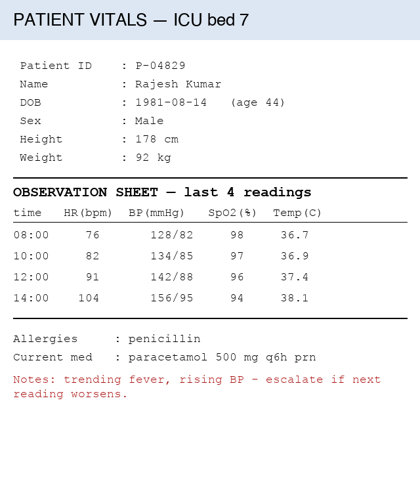

<div class="react-trace-block">
**Question:** Read the patient height and weight from this vitals chart, compute the BMI to one decimal place, note the trend in heart rate and blood pressure across the four readings, and recommend whether to escalate.

*Image: ICU vitals sheet (synthetic)*

*Ground truth:* `178 cm, 92 kg → BMI 29.0; HR 76→104, BP 128/82→156/95 (both rising); ESCALATE`

| Paradigm | Final answer |
|---|---|
| **1. Direct** | BMI is 29.1; HR and BP are both trending upward; escalate. |
| **2. CoT** | BMI is 29.0; heart rate and blood pressure are both trending upwards; recommendation is to escalate. |
| **3. Act-only** | (failed) |
| **4. ReAct** | The patient's height is 178 cm and weight is 92 kg, resulting in a BMI of 29.0. Both the heart rate (76 to 104 bpm) and blood pressure (128/82 to 156/95 mmHg) are trending upwards. Based on the notes stating "rising BP -… |

### Full traces
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>1. Direct</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">PROMPT:
Answer the question concisely in one short line.
Question: Read the patient height and weight from this vitals chart, compute the BMI to one decimal place, note the trend in heart rate and blood pressure across the four readings, and recommend whether to escalate.
Answer:

MODEL OUTPUT:
BMI is 29.1; HR and BP are both trending upward; escalate.</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>2. CoT</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">PROMPT:
Think step by step in plain text, then on the LAST line write &#x27;Final answer: &lt;answer&gt;&#x27;.

Question: Read the patient height and weight from this vitals chart, compute the BMI to one decimal place, note the trend in heart rate and blood pressure across the four readings, and recommend whether to escalate.

Reasoning:

MODEL OUTPUT:
1. **Identify Height and Weight**:
   - Height: 178 cm (1.78 meters)
   - Weight: 92 kg

2. **Compute BMI**:
   - Formula: $\text{BMI} = \frac{\text{weight (kg)}}{\text{height (m)}^2}$
   - Calculation: $92 / (1.78 \times 1.78) = 92 / 3.1684 \approx 29.037$
   - To one decimal place: 29.0

3. **Analyze Trends**:
   - **Heart Rate (HR)**: 76 $\rightarrow$ 82 $\rightarrow$ 91 $\rightarrow$ 104 bpm (Consistently increasing).
   - **Blood Pressure (BP)**: 128/82 $\rightarrow$ 134/85 $\rightarrow$ 142/88 $\rightarrow$ 156/95 mmHg (Consistently increasing).

4. **Recommendation**:
   - The patient&#x27;s heart rate and blood pressure are both trending upwards.
   - The temperature is also rising (36.7 $\rightarrow$ 38.1).
   - The notes explicitly state &quot;trending fever, rising BP - escalate if next reading worsens.&quot;
   - Given that the most recent readings (14:00) show a significant increase in HR, BP, and Temp, the patient&#x27;s condition is worsening.

Final answer: BMI is 29.0; heart rate and blood pressure are both trending upwards; recommendation is to escalate.</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>3. Act-only</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">You answer by emitting Action lines only. Do NOT think aloud. Each step is exactly one Action: tool[arg]. Stop with Finish[answer].
Available tools: Finish, calc, crop, describe

Question: Read the patient height and weight from this vitals chart, compute the BMI to one decimal place, note the trend in heart rate and blood pressure across the four readings, and recommend whether to escalate.

Thought 1: &lt;|tool_call&gt;call:crop[{&quot;box_2d&quot;: [258, 45, 336,
Observation 1: tool error: ValueError: could not convert string to float: &#x27;{&quot;box_2d&quot;: [258&#x27;
Thought 2: &lt;|tool_call&gt;call:crop[{&quot;box_2d&quot;: [258, 45, 33
Observation 2: tool error: ValueError: could not convert string to float: &#x27;{&quot;box_2d&quot;: [258&#x27;
Thought 3: &lt;|tool_call&gt;call:crop[{&quot;box_2d&quot;: [258, 45, 336,
Observation 3: tool error: ValueError: could not convert string to float: &#x27;{&quot;box_2d&quot;: [258&#x27;
Thought 4: &lt;|tool_call&gt;call:crop[{&quot;box_2d&quot;: [258, 45, 336,
Observation 4: tool error: ValueError: could not convert string to float: &#x27;{&quot;box_2d&quot;: [258&#x27;
[max steps]
</pre>
</details>
<details style="margin: 6px 0;"><summary style="cursor:pointer; padding:6px 0;">📜 <b>4. ReAct</b> — click to expand full trace</summary>
<pre style="font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; font-size: 14px; line-height: 1.55; white-space: pre-wrap; overflow-x: auto; max-height: 520px; background: #f6f8fa; color: #0d1117; padding: 12px 14px; border: 1px solid #d0d7de; border-radius: 6px; margin: 6px 0 16px 0;">You answer a question about an image by interleaving Thought, Action, and Observation.
Available tools:
  describe[]            - one full description of the image
  crop[x1,y1,x2,y2]     - re-look at a region (normalised 0..1 OR pixels)
  calc[expr]            - evaluate a numerical expression
  Finish[answer]        - final concise answer, stop

Format:
  Thought N: short reasoning
  Action N: tool_name[argument]
Use describe[] first; use crop[] to inspect a region. Stop within 5 steps with Finish[answer].

Question: Read the patient height and weight from this vitals chart, compute the BMI to one decimal place, note the trend in heart rate and blood pressure across the four readings, and recommend whether to escalate.

Thought 1: I will first extract the patient&#x27;s height and weight, then calculate the BMI, and finally analyze the trends in heart rate and blood pressure to determine if escalation is recommended.

Thought 1: I need to find the patient&#x27;s height and weight from the image.
Action 1: describe[]
Observation 1: A document titled &quot;PATIENT VITALS — ICU bed 7&quot; is displayed against a light blue header background. The rest of the document is white with black text.

Below the header, there is a section of patient identification:
*   **Patient ID:** P-04829
*   **Name:** Rajesh Kumar
*   **DOB:** 1981-08-14 (age 44)
*   **Sex:** Male
*   **Height:** 178 cm
*   **Weight:** 92 kg

A horizontal black line separates the identification from the &quot;OBSERVATION SHEET – last 4 readings&quot; section. This section contains a table with five columns:
*   **time:** 08:00, 10:00, 12:00, 14:00
*   **HR(bpm):** 76, 82, 91, 104

Thought 2: I have the height (178 cm) and weight (92 kg). Now I need to calculate the BMI. BMI = weight(kg) / (height(m)^2).
Action 2: calc[92 / (1.78 * 1.78)]
Observation 2: 29.036737785633125
Thought 3: The BMI is approximately 29.0. Now I need to analyze the trends in heart rate (HR) and blood pressure (BP) from the observation sheet.
- HR (bpm): 76 -&gt; 82 -&gt; 91 -&gt; 104 (Increasing)
- BP (mmHg): 128/82 -&gt; 134/85 -&gt; 142/88 -&gt; 156/95 (Increasing)
The notes also explicitly state &quot;trending fever, rising BP - escalate if next reading worsens.&quot; Since both HR and BP are steadily increasing, and the BP is rising, escalation is recommended.

Finish[The patient&#x27;s height is 178 cm and weight is 92 kg, resulting in a BMI of 29.0. Both the heart rate (76 to 104 bpm) and blood pressure (128/82 to 156/95 mmHg) are trending upwards. Based on the notes stating &quot;rising BP - escalate if next reading worsens,&quot; escalation is recommended.]

=&gt; The patient&#x27;s height is 178 cm and weight is 92 kg, resulting in a BMI of 29.0. Both the heart rate (76 to 104 bpm) and blood pressure (128/82 to 156/95 mmHg) are trending upwards. Based on the notes stating &quot;rising BP - escalate if next reading worsens,&quot; escalation is recommended.
</pre>
</details>
</div>

In [8]:
img = look_at('images/vitals.png')
disp = img.copy(); disp.thumbnail((420, 600))
display(disp)

_ = compare(
    'Read the patient height and weight from this vitals chart, compute the BMI to one decimal place, '
    'note the trend in heart rate and blood pressure across the four readings, and recommend whether to escalate.',
    VISION_TOOLS, VISION_SYSTEM,
    images=[img],
    image_label='ICU vitals sheet (synthetic)',
    ground_truth='178 cm, 92 kg → BMI 29.0; HR 76→104, BP 128/82→156/95 (both rising); ESCALATE')

## Takeaways

Reading down the four answer columns:

- **Direct** answers when the answer is one fact away. It hallucinates arithmetic and rarely admits uncertainty.
- **CoT** sometimes recovers what direct missed — its mental arithmetic on the compound-interest question lands close to the truth, but it can't query Wikipedia and (on Q4) it can't physically *see* the image well enough to extract numbers reliably.
- **Act-only** is the most brittle: a single tool call works fine, but multi-step tasks where the *next* call depends on the *previous* observation make it lose the thread.
- **ReAct** is the only paradigm that lands all four. The cost is overhead and format fragility — getting the regex permissive enough (registered tool names only; bare `Finish[…]` and `Finish: …`; tolerant crop coords; one-shot forcing prompt when Thought has no Action) is what turned a 50% success rate into a 100% one on this set.

What this means for picking a paradigm:

- **One known fact, no math** → Direct. Cheapest, fastest.
- **Reasoning over already-known facts** (proofs, code traces) → CoT.
- **Single tool call with a deterministic answer** → Act-only avoids the Thought tax.
- **Anything with two-or-more interleaved steps where each depends on the previous result** → ReAct.

Vision ReAct is fragile. The `crop[]` tool re-grounds the model on a region but the description-of-a-crop is still a translation through text; the model can mis-describe and the Thought has nothing to recover from. Native visual chain-of-thought (the model marking up the image directly) is what newer multimodal models are starting to do.

**Local cost.** Whole notebook end-to-end: ~3 min on an M2 Max with 18–20 GB peak. No API key, no per-token billing, every Thought/Action/Observation chain inspectable.